In [89]:
import numpy as np
import openmdao.api as om
import dymos as dm
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
import xarray as xr
import wecopttool as wot
 
#from dymos.examples.oscillator.oscillator_ode import OscillatorODE
%matplotlib inline


In [90]:
def td_to_fd(td, fft=True, zero_freq=True):
    """Convert a real array of time-domain responses to a complex array
    of Fourier coefficients."""

    td = np.atleast_1d(td)
    td = np.expand_dims(td, -1) if len(td.shape)==1 else td

    n = td.shape[0]
    if fft:
        fd = np.fft.rfft(td, n=n, axis=0, norm='forward')
    else:
        fd = np.dot(dft(n, 'n')[:n//2+1, :], td)
    fd = np.concatenate((fd[:1, :], fd[1:-1, :]*2, fd[-1:, :]))
    if not zero_freq:
        fd = fd[1:, :]
    return fd

def mimo_transfer_mat(transfer_mat,zero_freq = False):
    """Create a block matrix of the MIMO transfer function."""

    ndof = 1 #transfer_mat.shape[1]
    #assert transfer_mat.shape[2] == ndof
    elem = [[None]*ndof for _ in range(ndof)]
    def block(re, im): return np.array([[re, -im], [im, re]])
    for idof in range(ndof):
        for jdof in range(ndof):
            if zero_freq:
                Zp0 = transfer_mat[0]
                assert np.all(np.isreal(Zp0))
                Zp0 = np.real(Zp0)
                Zp = transfer_mat[1:]
            else:
                Zp0 = [0.0]
                Zp = transfer_mat[:]
            re = np.real(Zp)
            im = np.imag(Zp)
            blocks = [block(ire, iim) for (ire, iim) in zip(re[:-1], im[:-1])]
            blocks = [Zp0] + blocks + [re[-1]]
            elem[idof][jdof] = block_diag(*blocks)
    return np.block(elem)

def complex_to_real(fd, zero_freq = True):
    """Convert from one complex amplitude to two real amplitudes per
    frequency.    """

    fd = np.atleast_1d(fd)
    fd = np.expand_dims(fd, -1) if len(fd.shape)==1 else fd

    nfreq = fd.shape[0] - 1 if zero_freq else fd.shape[0]
    ndof = fd.shape[1]
    if zero_freq:
        #assert jnp.all(jnp.isreal(fd[0, :]))
        a = np.real(fd[0:1, :])
        b = np.real(fd[1:-1, :])
        c = np.imag(fd[1:-1, :])
        d = np.real(fd[-1:, :])
    else:
        b = np.real(fd[:-1, :])
        c = np.imag(fd[:-1, :])
        d = np.real(fd[-1:, :])
    out = np.concatenate([np.transpose(b), np.transpose(c)])
    out = np.reshape(np.reshape(out, [-1], order='F'), [-1, ndof])
    if zero_freq:
        out = np.concatenate([a, out, d])
        #assert out.shape == (2*nfreq, ndof)
    else:
        out = np.concatenate([out, d])
        #assert out.shape == (2*nfreq-1, ndof)
    return out

def time_func(f1, nfreq, nsubsteps = 1):
    """Assemble the time vector with :python:`nsubsteps` subdivisions.    """
    if nsubsteps < 1:
        raise ValueError("'nsubsteps' must be 1 or greater")
    nsteps = nsubsteps * 2 * nfreq
    return np.linspace(0, 1/f1, nsteps, endpoint=False)

def time_mat_func(f1, nfreq, nsubsteps = 1, zero_freq = True):
    """Assemble the time matrix that converts the state to a
    time-series.    """

    t = time_func(f1, nfreq, nsubsteps)
    omega = np.arange(0, nfreq+1)* f1 * 2*np.pi
    wt = np.outer(t, omega[1:])
    ncomp = 2*nfreq
    time_mat = np.empty((nsubsteps*ncomp, ncomp))
    
    time_mat[:, 0] = 1.0
    time_mat[:, 1::2] = np.cos(wt)
    time_mat[:, 2::2] = -np.sin(wt[:, :-1]) # remove 2pt wave sine component
    if not zero_freq:
        time_mat = time_mat[:, 1:]
    return time_mat


In [91]:
wavefreq = 0.1 # Hz
f1 = wavefreq
nfreq = 10
t_interp = np.linspace(0, 1/f1, 2*nfreq, endpoint=False)
t_interp_full = np.linspace(0, 1/f1, 2*nfreq+1, endpoint=True)

bem_data = xr.open_dataset('bem_wb_10.nc')

def excitation_force_sincos_from_waves_vec(exc_coeff: xr.DataArray,
                                           waves: xr.DataArray,
                                           t: np.ndarray) -> np.ndarray:
    t = np.asarray(t)

    if waves.sizes.get('wave_direction', 1) != 1:
        raise ValueError("waves must contain exactly one wave_direction.")
    wave_dir = float(waves['wave_direction'].values[0])

    exc_d = exc_coeff.sel(wave_direction=wave_dir)
    wav_d = waves.sel(wave_direction=wave_dir)

    # If exc_coeff still has a 'complex' dim, combine it here
    if 'complex' in exc_d.dims:
        exc_d = exc_d.sel(complex='re') + 1j * exc_d.sel(complex='im')

    if exc_d.sizes.get('influenced_dof', 1) != 1:
        raise ValueError("exc_coeff must have exactly one influenced_dof.")
    exc_d = exc_d.isel(influenced_dof=0)

    omega_e = exc_d['omega'].values
    omega_w = wav_d['omega'].values
    if omega_e.shape != omega_w.shape or not np.array_equal(omega_e, omega_w):
        raise ValueError("omega grids do not match exactly.")

    omega = omega_e.astype(float)  # (n_omega,)

    Fk = np.asarray(exc_d.values * wav_d.values, dtype=np.complex128).squeeze()
    # Force shape (n_omega,)
    Fk = Fk.reshape((-1,))

    wt = omega[:, None] * t[None, :]   # (n_omega, n_t)
    c = np.cos(wt)
    s = np.sin(wt)

    return (Fk.real[:, None] * c - Fk.imag[:, None] * s).sum(axis=0)

In [92]:
class OscillatorODE(om.ExplicitComponent):
    """
    A Dymos ODE for a damped harmonic oscillator. 
    Current option is 1 dof.
    """

    def initialize(self):
        self.options.declare('num_nodes', types=int)
        # "Constants" moved from inputs to options
        self.options.declare('m', types=(int, float, np.ndarray, xr.DataArray), desc='mass [kg]')
        self.options.declare('wave_freq', types=(int, float), desc='fundamental frequency [Hz]')
        self.options.declare('waves', types=(int, float, np.ndarray, xr.DataArray), desc='waves ')

        # If these are also constants in your usage, move them too
        self.options.declare('t_interp', types=np.ndarray, desc='timeseries for interpolation')
        self.options.declare('omega', types=(np.ndarray, xr.DataArray), desc='frequencies [rad/s]')
        self.options.declare('excitation_force', types=(int, float, np.ndarray, xr.DataArray), desc='excitation force coefficients [N]')
        self.options.declare('radiation_damping', types=(np.ndarray, xr.DataArray), desc='radiation damping coefficients')
        self.options.declare('added_mass', types=(np.ndarray, xr.DataArray), desc='added mass coefficients')
        self.options.declare('hydrostatic_stiffness', types=(int, float, np.ndarray, xr.DataArray), desc='hydrostatic stiffness coefficients [N/m]')

        # If you need these too (they were referenced in compute but not defined here)
        self.options.declare('nfreq', types=int, desc='number of frequencies')
        self.options.declare('f1', default=None, desc='arg for time_mat_func (as used in your code)')
        self.options.declare('t_interp_full', default=None, desc='full interpolation time vector used in your code')

    def setup(self):
        nn = self.options['num_nodes']
        nf = self.options['nfreq']
        ar = np.arange(nn)

        # Inputs
        self.add_input('x', shape=(nn,), desc='displacement', units='m')
        self.add_input('v', shape=(nn,), desc='velocity', units='m/s')
        self.add_input('time',shape=(nn,),desc='time',units='s') # New input for time
        #self.add_input("u", shape=(nn,), units="N", desc="control force applied") # control force

        self.add_output('v_dot', val=np.zeros(nn), desc='rate of change of velocity', units='m/s**2')
        self.add_output("power", shape=(nn,), units="W", desc="power to be integrated")
        self.add_output("x_dot", shape=(nn,), desc="rate of change of displacement", units="m/s") # for integration

        # v_dot wrt vector inputs (diagonal)
        self.declare_partials('v_dot', 'x', rows=ar, cols=ar)
        self.declare_partials('v_dot', 'v', method='fd') # forward differentiation since we use frequency dependent damping
        #self.declare_partials('v_dot', 'u', rows=ar, cols=ar)
        #self.declare_partials('v_dot', 'time', rows=ar, cols=ar)

        # power wrt vector inputs (diagonal)
        self.declare_partials('power', 'v', rows=ar, cols=ar)
        #self.declare_partials('power', 'u', rows=ar, cols=ar)

        self.declare_partials('x_dot', 'v', rows=ar, cols=ar)

    def compute(self, inputs, outputs):
        x = inputs['x']
        v = inputs['v']
        t = inputs['time']
        #u = inputs['u']
        
        m = self.options['m']
        wave_freq = self.options['wave_freq']
        waves = self.options['waves']

        t_interp = self.options['t_interp']
        omega = self.options['omega']
        excitation_force = self.options['excitation_force']
        radiation_damping = self.options['radiation_damping']
        added_mass = self.options['added_mass']
        hydrostatic_stiffness = self.options['hydrostatic_stiffness']

        nfreq = self.options['nfreq']
        f1 = self.options['f1']
        t_interp_full = self.options['t_interp_full']

        # convert velocity to frequency domain
        t_round = np.round(t, 14)
        v_interp = np.interp(t_interp,t_round,v)
        v_fd = wot.td_to_fd(v_interp)
        v_fd_real = wot.complex_to_real(v_fd)

        rao_transfer_func_rad = -radiation_damping + 1j*omega*added_mass
        transfer_mat = wot.mimo_transfer_mat(rao_transfer_func_rad, False)
        time_matrix = wot.time_mat(f1, nfreq)

        rad_fd = np.dot(transfer_mat,v_fd_real) #  
        radiation_damping_force_td = np.dot(time_matrix,rad_fd)
        radiation_damping_force_td = np.append(radiation_damping_force_td, radiation_damping_force_td[0])
        radiation_damping_force_td_interp = np.interp(t,t_interp_full,np.squeeze(radiation_damping_force_td))

        f_hydrostatic_stiffness = -hydrostatic_stiffness * x
        #f_control = u

        excitation_force_ts = excitation_force_sincos_from_waves_vec(excitation_force,
                              waves.sel(realization=0),  # wave_elev(omega,wave_direction)
                              t=t)

        outputs['v_dot'] = (f_hydrostatic_stiffness + radiation_damping_force_td_interp + excitation_force_ts) / m # this is the residual
        outputs['power'] = 0*v # power is control force*velocity
        outputs['x_dot'] = v # for integration

    def compute_partials(self, inputs, partials):
        nn = self.options['num_nodes']

        x = inputs['x']
        v = inputs['v']
        t = inputs['time']
        #u = inputs['u']

        m = self.options['m']

        hydrostatic_stiffness = self.options['hydrostatic_stiffness']

        partials['v_dot', 'x'] = (-hydrostatic_stiffness / m) * np.ones(nn)
        #partials['v_dot', 'time'] = -exc_amp*w*np.sin(w*t) / m
        #partials['v_dot', 'u'] = (1 / m) * np.ones(nn)
        
        partials['power', 'v'] = 0
        #partials['power', 'u'] = v

        partials['x_dot', 'v'] = np.ones(nn)

In [ ]:

driver=om.pyOptSparseDriver()
optimizer = 'IPOPT'
transcription=dm.GaussLobatto(num_segments=10, order=3)
scale_x_wec=1
scale_control=1e-2
scale_energy=1e-3

# Instantiate an OpenMDAO Problem instance.
prob = om.Problem()

# We need an optimization driver.  To solve this simple problem ScipyOptimizerDriver will work.
#prob.driver = om.ScipyOptimizeDriver(maxiter=500)
prob.driver = driver
prob.driver.options['optimizer'] = optimizer
prob.driver.declare_coloring()

# Instantiate a Dymos Trajectory and add it to the Problem model.
traj = dm.Trajectory()
prob.model.add_subsystem('traj', traj)

t_interp = np.linspace(0, 1/f1, 2*nfreq, endpoint=False)
t_interp_full = np.linspace(0, 1/f1, 2*nfreq+1, endpoint=True)

amplitude = 0.0625 # m
phase = 30 # degrees
wavedir = 0 # degrees
waves = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude=amplitude, phase=phase, direction=wavedir)

# Instantiate a Phase and add it to the Trajectory.
phase = dm.Phase(ode_class=OscillatorODE, transcription=transcription,
                ode_init_kwargs=dict(
                    m=float(np.squeeze(bem_data['inertia_matrix'].values)),
                    excitation_force=bem_data['excitation_force'],
                    waves=waves,
                    wave_freq=wavefreq,
                    t_interp=t_interp, 
                    omega=bem_data['omega'], 
                    radiation_damping=bem_data['radiation_damping'], 
                    added_mass=bem_data['added_mass'], 
                    hydrostatic_stiffness=float(np.squeeze(bem_data['hydrostatic_stiffness'].values)),  # Add comma here
                    nfreq=nfreq,
                    f1=f1,
                    t_interp_full=t_interp_full)
                    )
traj.add_phase('phase0', phase)

# Tell Dymos that the duration of the phase is bounded.
phase.set_time_options(fix_initial=True, fix_duration=True, targets=['time'])

# Tell Dymos the states to be propagated using the given ODE.
phase.add_state('x', fix_initial=False, fix_final=False, rate_source='x_dot', scaler=scale_x_wec, targets=['x'], units='m')
phase.add_state('v', fix_initial=False, fix_final=False, rate_source='v_dot', targets=['v'], units='m/s')
phase.add_state('energy', fix_initial=True, rate_source='power', ref=10, defect_ref=1, units='J')  # integration of power

#phase.add_control('u', fix_initial=False, rate_continuity=False, opt=True, continuity=True, lower=-300, upper=300, scaler=scale_control, units='N')

# Enforce periodic states: final = initial
#traj.link_phases(phases=['phase0', 'phase0'], vars=['x','v'], locs=('final', 'initial'))

phase.add_timeseries_output('time', output_name='time')

# Since we're using an optimization driver, an objective is required.  We'll minimize
# the final time in this case.
#phase.add_objective('energy', loc='final',scaler=scale_energy)
#prob.model.linear_solver = om.DirectSolver()
phase.add_objective('time', loc='final')

# Setup the OpenMDAO problem
prob.setup()

# Assign values to the times and states
phase.set_time_val(0.0, t_interp_full[-1]) # 1 period
phase.set_state_val('x', vals=[1.0, 1.0], time_vals=[0.0, t_interp_full[-1]])
phase.set_state_val('v', vals=[0.0,0.0], time_vals=[0.0, t_interp_full[-1]])
#phase.set_control_val('u', vals=[0.0, 0.0], time_vals=[0.0, t_interp_full[-1]])
phase.set_state_val('energy', vals=[0.0,0], time_vals=[0.0, t_interp_full[-1]])

In [94]:
#prob.run_model()
prob.run_driver()
sim_out = traj.simulate(times_per_seg=20)

# Plot the state values obtained from the phase timeseries objects in the simulation output.
t_sol = prob.get_val('traj.phase0.timeseries.time')
t_sim = sim_out.get_val('traj.phase0.timeseries.time')


c:\Users\jtgrasb\AppData\Local\anaconda3\envs\dymos_wot\lib\site-packages\openmdao\core\driver.py:1276: DriverWarning:pyOptSparseDriver: objective(s) ['traj.phase0.t'] do not depend on any design variables. Please check your problem formulation.



Jacobian shape: (121, 122)  (46.86% nonzero)
FWD solves: 82   REV solves: 0
Total colors vs. total size: 82 vs 122  (32.79% improvement)

Sparsity computed using tolerance: 1e-25.
Dense total jacobian for Problem 'problem13' was computed 3 times.
Time to compute sparsity:  52.1274 sec
Time to compute coloring:   1.1228 sec
Memory to compute coloring:   2.1094 MB
Coloring created on: 2026-03-10 17:04:51


c:\Users\jtgrasb\AppData\Local\anaconda3\envs\dymos_wot\lib\site-packages\openmdao\core\total_jac.py:1670: DerivativesWarning:The following constraints or objectives cannot be impacted by the design variables of the problem at the current design point:
  traj.phase0.t, inds=[99]





Optimization Problem -- Optimization using pyOpt_sparse
    Objective Function: _objfunc

    Solution: 
--------------------------------------------------------------------------------
    Total Time:                   20.2998
       User Objective Time :       0.4730
       User Sensitivity Time :    19.7322
       Interface Time :            0.0135
       Opt Solver Time:            0.0811
    Calls to Objective Function :       2
    Calls to Sens Function :            2


   Objectives
      Index  Name                     Value
          0  traj.phase0.t     1.000000E+01

   Variables (c - continuous, i - integer, d - discrete)
      Index  Name                           Type      Lower Bound            Value      Upper Bound     Status
          0  traj.phase0.states:x_0            c    -1.000000E+21     5.181130E-02     1.000000E+21           
          1  traj.phase0.states:x_1            c    -1.000000E+21     5.065239E-02     1.000000E+21           
          2  traj.phase

c:\Users\jtgrasb\AppData\Local\anaconda3\envs\dymos_wot\lib\site-packages\openmdao\visualization\opt_report\opt_report.py:611: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([ymin_plot, ymax_plot])



Simulating trajectory traj
Done simulating trajectory traj


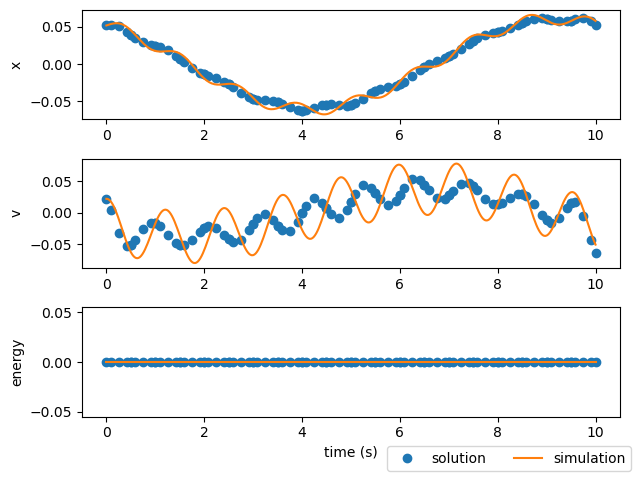

In [95]:
states = ['x', 'v','energy']
fig, axes = plt.subplots(len(states), 1)
for i, state in enumerate(states):
    sol = axes[i].plot(t_sol, prob.get_val(f'traj.phase0.timeseries.{state}'), 'o')
    sim = axes[i].plot(t_sim, sim_out.get_val(f'traj.phase0.timeseries.{state}'), '-')
    axes[i].set_ylabel(state)
axes[-1].set_xlabel('time (s)')
fig.legend((sol[0], sim[0]), ('solution', 'simulation'), loc='lower right', ncol=2)
plt.tight_layout()
plt.show()
